# 5.1 Сравнение режимов адаптации

В этом ноутбуке сравниваются два режима адаптации сложности:
- `baseline` — эвристический режим;
- `ppo` — модельный режим.

Задача этого раздела — понять, действительно ли модельный режим даёт преимущество по сравнению с эвристикой. Для этого анализ строится на нескольких уровнях: по отдельным задачам, по сессиям, по участникам и по подгруппам пользователей.

Если модельный режим лучше, то пользователи должны чаще успевать отвечать, чаще отвечать правильно, тратить меньше времени на ответ или сохранять качество ответа при меньшем времени реакции. Также важно понять, является ли эффект устойчивым у разных людей, а не только в отдельных сессиях.

**Ноутбук отвечает на вопросы:**
1. Отличаются ли режимы по базовым показателям успешности прохождения: точности, доле отвеченных задач, времени ответа и числу успешно решённых задач?
2. Сохраняется ли различие не только на уровне сессий, но и на уровне самих участников?
3. Улучшает ли модельный режим нормализованные показатели продуктивности, если убрать влияние разной длины сессий?
4. Наблюдается ли преимущество модели у большинства участников, у которых есть опыт обоих режимов?
5. Подтверждаются ли различия статистическими тестами?
6. Одинаково ли работает адаптация в разных возрастных, гендерных и игровых подгруппах?

**Как читать результаты**
- Высокие значения `accuracy_total` и `answered_rate` считаются положительным результатом.
- Низкие значения `mean_rt_ms` и `median_rt_ms` считаются положительным результатом, потому что означают более быстрый ответ.
- Метрика `solved_tasks` важна как прикладной показатель: она показывает, сколько задач пользователь довёл до правильного решения.
- Метрика `level_gain` отражает продвижение по уровням сложности.

In [1]:
from importlib import reload
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import notebook_utils as nu

nu = reload(nu)


In [2]:
DATA_DIR = Path("data")

task_df = pd.read_csv(DATA_DIR / "task_table.csv")
session_df = pd.read_csv(DATA_DIR / "session_table.csv")
participant_mode_df = pd.read_csv(DATA_DIR / "participant_mode_table.csv")

print("task_df:", task_df.shape)
print("session_df:", session_df.shape)
print("participant_mode_df:", participant_mode_df.shape)


task_df: (17820, 23)
session_df: (95, 21)
participant_mode_df: (53, 19)


## Подготовка выборки для корректного сравнения

Для строгого сравнения режимов в этом ноутбуке дальше используются только те участники, которые играли **и в `baseline`, и в `ppo`**.



In [3]:
task_df_full = task_df.copy()
session_df_full = session_df.copy()
participant_mode_df_full = participant_mode_df.copy()

participant_modes = participant_mode_df_full.groupby("participant_id")["mode"].agg(lambda values: set(values))
paired_ids = participant_modes[participant_modes.apply(lambda modes: {"baseline", "ppo"}.issubset(modes))].index.tolist()
baseline_only_ids = participant_modes[participant_modes.apply(lambda modes: modes == {"baseline"})].index.tolist()
ppo_only_ids = participant_modes[participant_modes.apply(lambda modes: modes == {"ppo"})].index.tolist()

task_df = task_df_full[task_df_full["participant_id"].isin(paired_ids)].copy()
session_df = session_df_full[session_df_full["participant_id"].isin(paired_ids)].copy()
participant_mode_df = participant_mode_df_full[participant_mode_df_full["participant_id"].isin(paired_ids)].copy()

print("Структура полного набора данных:")
print(f"- участников всего: {participant_mode_df_full['participant_id'].nunique()}")
print(f"- участников с baseline: {participant_mode_df_full.loc[participant_mode_df_full['mode'] == 'baseline', 'participant_id'].nunique()}")
print(f"- участников с ppo: {participant_mode_df_full.loc[participant_mode_df_full['mode'] == 'ppo', 'participant_id'].nunique()}")
print(f"- участников с обоими режимами: {len(paired_ids)}")
print(f"- только baseline: {len(baseline_only_ids)}")
print(f"- только ppo: {len(ppo_only_ids)}")
print()
print("Размер аналитической выборки после фильтрации по двум режимам:")
print(f"- task_df: {task_df.shape}")
print(f"- session_df: {session_df.shape}")
print(f"- participant_mode_df: {participant_mode_df.shape}")


Структура полного набора данных:
- участников всего: 34
- участников с baseline: 34
- участников с ppo: 19
- участников с обоими режимами: 19
- только baseline: 15
- только ppo: 0

Размер аналитической выборки после фильтрации по двум режимам:
- task_df: (13439, 23)
- session_df: (75, 21)
- participant_mode_df: (38, 19)


## 1. Объём и структура аналитической выборки

In [4]:
mode_counts = pd.DataFrame({"tasks": task_df.groupby("mode").size(),"sessions": session_df.groupby("mode").size(),"participants": participant_mode_df.groupby("mode")["participant_id"].nunique()}).fillna(0).astype(int)
mode_counts


,tasks,sessions,participants
mode,,,
baseline,8384,47,19
ppo,5055,28,19


In [5]:
if {"baseline", "ppo"}.issubset(mode_counts.index):
    b_tasks = int(mode_counts.loc["baseline", "tasks"])
    p_tasks = int(mode_counts.loc["ppo", "tasks"])
    b_sessions = int(mode_counts.loc["baseline", "sessions"])
    p_sessions = int(mode_counts.loc["ppo", "sessions"])
    b_participants = int(mode_counts.loc["baseline", "participants"])
    p_participants = int(mode_counts.loc["ppo", "participants"])
    print(f"- В baseline собрано {b_tasks} задач, {b_sessions} сессий и {b_participants} участников.")
    print(f"- В ppo собрано {p_tasks} задач, {p_sessions} сессий и {p_participants} участников.")
    if b_sessions > 0 and p_sessions > 0:
        print(f"- По числу сессий baseline больше примерно в {b_sessions / p_sessions:.2f} раза.")
    if b_participants > 0 and p_participants > 0:
        print(f"- По числу участников baseline больше примерно в {b_participants / p_participants:.2f} раза.")

- В baseline собрано 8384 задач, 47 сессий и 19 участников.
- В ppo собрано 5055 задач, 28 сессий и 19 участников.
- По числу сессий baseline больше примерно в 1.68 раза.
- По числу участников baseline больше примерно в 1.00 раза.


## 2. Проверка сопоставимости длины сессий

Отличаются ли режимы по общему объёму работы внутри сессии:
- сколько задач в среднем предъявляется;
- сколько задач пользователь успевает обработать;
- какова длительность сессии и охват батчей.



In [6]:
length_columns = [col for col in ['total_tasks', 'answered_tasks', 'solved_tasks','task_span_minutes','completed_batches'] if col in session_df.columns]
session_length_summary = (session_df.groupby('mode')[length_columns].agg(['mean', 'median']).round(2))
session_length_summary


total_tasks        answered_tasks        solved_tasks         \
                mean median           mean median         mean median   
mode                                                                    
baseline      178.38   70.0         171.19   67.0       151.13   63.0   
ppo           180.54   90.0         178.04   90.0       165.29   82.0   

         task_span_minutes        completed_batches         
                      mean median              mean median  
mode                                                        
baseline           1781.89   9.07             18.23    7.0  
ppo                 262.40   4.72             18.14    9.0

In [7]:
if {'baseline', 'ppo'}.issubset(session_df['mode'].unique()):
    base = session_df[session_df['mode'] == 'baseline']
    model = session_df[session_df['mode'] == 'ppo']
    if 'total_tasks' in session_df.columns:
        print(f"- В baseline в среднем предъявляется {base['total_tasks'].mean():.1f} задач за сессию, а в ppo — {model['total_tasks'].mean():.1f}.")
    if 'answered_tasks' in session_df.columns:
        print(f"- В baseline пользователь в среднем отвечает на {base['answered_tasks'].mean():.1f} задач, а в ppo — на {model['answered_tasks'].mean():.1f}.")
    if 'task_span_minutes' in session_df.columns:
        print(f"- Средняя длительность сессии: baseline = {base['task_span_minutes'].mean():.2f} мин, ppo = {model['task_span_minutes'].mean():.2f} мин.")

- В baseline в среднем предъявляется 178.4 задач за сессию, а в ppo — 180.5.
- В baseline пользователь в среднем отвечает на 171.2 задач, а в ppo — на 178.0.
- Средняя длительность сессии: baseline = 1781.89 мин, ppo = 262.40 мин.


## 3. Средние метрики по сессиям

Сравниваются следующие показатели:
- `accuracy_total_mean` — средняя доля правильно решённых задач среди всех предъявленных;
- `answered_rate_mean` — средняя доля задач, на которые пользователь успел ответить;
- `mean_rt_ms_mean` — среднее время ответа в миллисекундах;
- `median_rt_ms_mean` — медианное время ответа;
- `level_gain_mean` — средний прирост уровня внутри сессии;
- `solved_tasks_mean` — среднее число успешно решённых задач;
- `answered_tasks_mean` — среднее число задач с ответом;
- `total_tasks_mean` — среднее число предъявленных задач.

In [8]:
session_mode_summary = nu.mode_summary_table(session_df)
session_mode_summary


,mode,rows,participants,accuracy_total_mean,answered_rate_mean,mean_rt_ms_mean,median_rt_ms_mean,level_gain_mean,solved_tasks_mean,answered_tasks_mean,total_tasks_mean
0,baseline,47,19,0.690353,0.811905,2009.029772,1829.317073,4.340426,151.127660,171.191489,178.382979
1,ppo,28,19,0.861733,0.964760,1811.253812,1577.946429,5.285714,165.285714,178.035714,180.535714


In [9]:

if {"baseline", "ppo"}.issubset(set(session_mode_summary["mode"])):
    b = session_mode_summary.set_index("mode").loc["baseline"]
    p = session_mode_summary.set_index("mode").loc["ppo"]
    print(f"- По сессиям средняя итоговая точность в ppo составляет {p['accuracy_total_mean']:.3f}, а в baseline — {b['accuracy_total_mean']:.3f}.")
    if p['accuracy_total_mean'] > b['accuracy_total_mean']:
        print("- Это говорит о том, что в среднем сессии в модельном режиме завершаются с более высокой долей правильных решений.")
    else:
        print("- На уровне сессий модельный режим не показывает преимущества по итоговой точности.")

    print()
    print(f"- Доля отвеченных задач в ppo равна {p['answered_rate_mean']:.3f}, а в baseline — {b['answered_rate_mean']:.3f}.")
    if p['answered_rate_mean'] > b['answered_rate_mean']:
        print("- Это означает, что в ppo пользователи чаще успевают дать ответ и реже теряют задачи из-за пропуска или нехватки времени.")
    else:
        print("- Это означает, что ppo не даёт преимущества по охвату задач внутри сессии.")

    print()
    print(f"- Среднее время ответа в ppo равно {p['mean_rt_ms_mean']:.1f} мс, а в baseline — {b['mean_rt_ms_mean']:.1f} мс.")
    if p['mean_rt_ms_mean'] < b['mean_rt_ms_mean']:
        print("- В этом наборе данных модельный режим сопровождается более быстрым реагированием, что особенно ценно, если при этом не снижается точность.")
    else:
        print("- В этом наборе данных модельный режим не ускоряет ответы.")

    print()
    print(f"- Среднее число успешно решённых задач на сессию: ppo = {p['solved_tasks_mean']:.1f}, baseline = {b['solved_tasks_mean']:.1f}.")
    

- По сессиям средняя итоговая точность в ppo составляет 0.862, а в baseline — 0.690.
- Это говорит о том, что в среднем сессии в модельном режиме завершаются с более высокой долей правильных решений.

- Доля отвеченных задач в ppo равна 0.965, а в baseline — 0.812.
- Это означает, что в ppo пользователи чаще успевают дать ответ и реже теряют задачи из-за пропуска или нехватки времени.

- Среднее время ответа в ppo равно 1811.3 мс, а в baseline — 2009.0 мс.
- В этом наборе данных модельный режим сопровождается более быстрым реагированием, что особенно ценно, если при этом не снижается точность.

- Среднее число успешно решённых задач на сессию: ppo = 165.3, baseline = 151.1.


## 4. Средние метрики по участникам

Здесь несколько сессий одного и того же человека объединяются в один профиль участника внутри режима.

Зачем это нужно:
- чтобы уменьшить влияние пользователей, которые играли особенно много;
- чтобы оценить типичное поведение участника, а не отдельной сессии;
- чтобы затем можно было построить парные сравнения между режимами у одних и тех же людей.


In [10]:
participant_mode_summary = (
    participant_mode_df
    .groupby('mode', as_index=False)
    .agg(
        rows=('participant_id', 'size'),
        participants=('participant_id', 'nunique'),
        accuracy_total_mean=('accuracy_total', 'mean'),
        answered_rate_mean=('answered_rate', 'mean'),
        mean_rt_ms_mean=('mean_rt_ms', 'mean'),
        median_rt_ms_mean=('median_rt_ms', 'mean'),
        level_gain_mean=('level_gain_mean', 'mean'),
        solved_tasks_per_session_mean=('solved_tasks_per_session', 'mean'),
        answered_tasks_per_session_mean=('answered_tasks_per_session', 'mean'),
        total_tasks_per_session_mean=('total_tasks_per_session', 'mean'),
    )
)
participant_mode_summary


,mode,rows,participants,accuracy_total_mean,answered_rate_mean,mean_rt_ms_mean,median_rt_ms_mean,level_gain_mean,solved_tasks_per_session_mean,answered_tasks_per_session_mean,total_tasks_per_session_mean
0,baseline,19,19,0.817874,0.944808,2150.486223,1972.762281,5.438836,225.351116,253.686364,263.972807
1,ppo,19,19,0.872988,0.954821,1825.621247,1583.133772,6.118421,160.061404,173.548246,176.438596


In [11]:
if {"baseline", "ppo"}.issubset(set(participant_mode_summary["mode"])):
    b = participant_mode_summary.set_index("mode").loc["baseline"]
    p = participant_mode_summary.set_index("mode").loc["ppo"]
    print(f"- На уровне участников средняя точность составляет {b['accuracy_total_mean']:.3f} для baseline и {p['accuracy_total_mean']:.3f} для ppo.")
    print(f"- Средняя доля отвеченных задач: baseline = {b['answered_rate_mean']:.3f}, ppo = {p['answered_rate_mean']:.3f}.")
    print(f"- Среднее время ответа: baseline = {b['mean_rt_ms_mean']:.1f} мс, ppo = {p['mean_rt_ms_mean']:.1f} мс.")
    print(f"- Среднее число успешно решённых задач на сессию: baseline = {b['solved_tasks_per_session_mean']:.1f}, ppo = {p['solved_tasks_per_session_mean']:.1f}.")

- На уровне участников средняя точность составляет 0.818 для baseline и 0.873 для ppo.
- Средняя доля отвеченных задач: baseline = 0.945, ppo = 0.955.
- Среднее время ответа: baseline = 2150.5 мс, ppo = 1825.6 мс.
- Среднее число успешно решённых задач на сессию: baseline = 225.4, ppo = 160.1.


## 5. Нормализованные показатели продуктивности

Pдесь добавляются показатели, которые нормируют результат на объём предъявленного материала.

Используются следующие метрики:
- `solved_per_100_tasks` — сколько задач решается правильно на каждые 100 предъявленных;
- `answered_per_100_tasks` — сколько задач получают ответ на каждые 100 предъявленных;
- `relative_accuracy_to_baseline_pct` — относительное изменение точности по сравнению с baseline;
- `relative_rt_to_baseline_pct` — относительное изменение времени ответа по сравнению с baseline.


In [12]:
normalized_summary = participant_mode_df.groupby('mode', as_index=False).agg(
    participants=('participant_id', 'nunique'),
    total_tasks=('total_tasks', 'sum'),
    answered_tasks=('answered_tasks', 'sum'),
    solved_tasks=('solved_tasks', 'sum'),
    mean_rt_ms=('mean_rt_ms', 'mean'),
    accuracy_total=('accuracy_total', 'mean'),
    answered_rate=('answered_rate', 'mean'),
)
normalized_summary['solved_per_100_tasks'] = normalized_summary['solved_tasks'] / normalized_summary['total_tasks'] * 100
normalized_summary['answered_per_100_tasks'] = normalized_summary['answered_tasks'] / normalized_summary['total_tasks'] * 100

if {'baseline', 'ppo'}.issubset(set(normalized_summary['mode'])):
    baseline_row = normalized_summary.set_index('mode').loc['baseline']
    normalized_summary['relative_accuracy_to_baseline_pct'] = (normalized_summary['accuracy_total'] / baseline_row['accuracy_total'] - 1) * 100
    normalized_summary['relative_rt_to_baseline_pct'] = (normalized_summary['mean_rt_ms'] / baseline_row['mean_rt_ms'] - 1) * 100

normalized_summary


,mode,participants,total_tasks,answered_tasks,solved_tasks,mean_rt_ms,accuracy_total,answered_rate,solved_per_100_tasks,answered_per_100_tasks,relative_accuracy_to_baseline_pct,relative_rt_to_baseline_pct
0,baseline,19,8384,8046,7103,2150.486223,0.817874,0.944808,84.720897,95.968511,0.000000,0.000000
1,ppo,19,5055,4985,4628,1825.621247,0.872988,0.954821,91.552918,98.615232,6.738617,-15.106583


In [13]:
if {'baseline', 'ppo'}.issubset(set(normalized_summary['mode'])):
    b = normalized_summary.set_index('mode').loc['baseline']
    p = normalized_summary.set_index('mode').loc['ppo']
    print(f"- В baseline успешно решается {b['solved_per_100_tasks']:.1f} задач на 100 предъявленных, в ppo — {p['solved_per_100_tasks']:.1f}.")
    print(f"- В baseline ответ даётся на {b['answered_per_100_tasks']:.1f} задач из 100, в ppo — на {p['answered_per_100_tasks']:.1f}.")
    print(f"- Относительное изменение точности ppo по сравнению с baseline составляет {p['relative_accuracy_to_baseline_pct']:.2f}%.")
    print(f"- Относительное изменение среднего времени ответа ppo по сравнению с baseline составляет {p['relative_rt_to_baseline_pct']:.2f}%.")
    

- В baseline успешно решается 84.7 задач на 100 предъявленных, в ppo — 91.6.
- В baseline ответ даётся на 96.0 задач из 100, в ppo — на 98.6.
- Относительное изменение точности ppo по сравнению с baseline составляет 6.74%.
- Относительное изменение среднего времени ответа ppo по сравнению с baseline составляет -15.11%.


## 6. Размер эффекта и практическая значимость

Ниже рассчитывается практический размер эффекта: насколько процентов меняются ключевые метрики в `ppo` относительно `baseline`.


In [14]:
effect_table = []
for metric, better in [
    ('accuracy_total', 'higher'),
    ('answered_rate', 'higher'),
    ('mean_rt_ms', 'lower'),
    ('solved_tasks_per_session', 'higher'),
    ('level_gain_mean', 'higher'),
]:
    pivot = participant_mode_df.groupby('mode')[metric].mean()
    if {'baseline', 'ppo'}.issubset(pivot.index):
        baseline_value = float(pivot['baseline'])
        ppo_value = float(pivot['ppo'])
        delta = ppo_value - baseline_value
        if baseline_value != 0:
            relative = delta / baseline_value * 100
        else:
            relative = np.nan
        effect_table.append({
            'metric': metric,
            'baseline_mean': baseline_value,
            'ppo_mean': ppo_value,
            'delta_model_minus_baseline': delta,
            'relative_change_pct': relative,
            'better_direction': better,
        })

effect_table = pd.DataFrame(effect_table)
effect_table


,metric,baseline_mean,ppo_mean,delta_model_minus_baseline,relative_change_pct,better_direction
0,accuracy_total,0.817874,0.872988,0.055113,6.738617,higher
1,answered_rate,0.944808,0.954821,0.010013,1.059830,higher
2,mean_rt_ms,2150.486223,1825.621247,-324.864977,-15.106583,lower
3,solved_tasks_per_session,225.351116,160.061404,-65.289713,-28.972438,higher
4,level_gain_mean,5.438836,6.118421,0.679585,12.495052,higher


In [15]:
if not effect_table.empty:
    for _, row in effect_table.iterrows():
        metric = row['metric']
        delta = row['delta_model_minus_baseline']
        rel = row['relative_change_pct']
        if row['better_direction'] == 'higher':
            direction_text = 'рост' if delta > 0 else 'снижение'
        else:
            direction_text = 'снижение' if delta < 0 else 'рост'
        print(f"- Для метрики {metric} модельный режим даёт {direction_text} на {abs(rel):.2f}% относительно baseline.")

- Для метрики accuracy_total модельный режим даёт рост на 6.74% относительно baseline.
- Для метрики answered_rate модельный режим даёт рост на 1.06% относительно baseline.
- Для метрики mean_rt_ms модельный режим даёт снижение на 15.11% относительно baseline.
- Для метрики solved_tasks_per_session модельный режим даёт снижение на 28.97% относительно baseline.
- Для метрики level_gain_mean модельный режим даёт рост на 12.50% относительно baseline.


## 7. Визуальное сравнение основных метрик

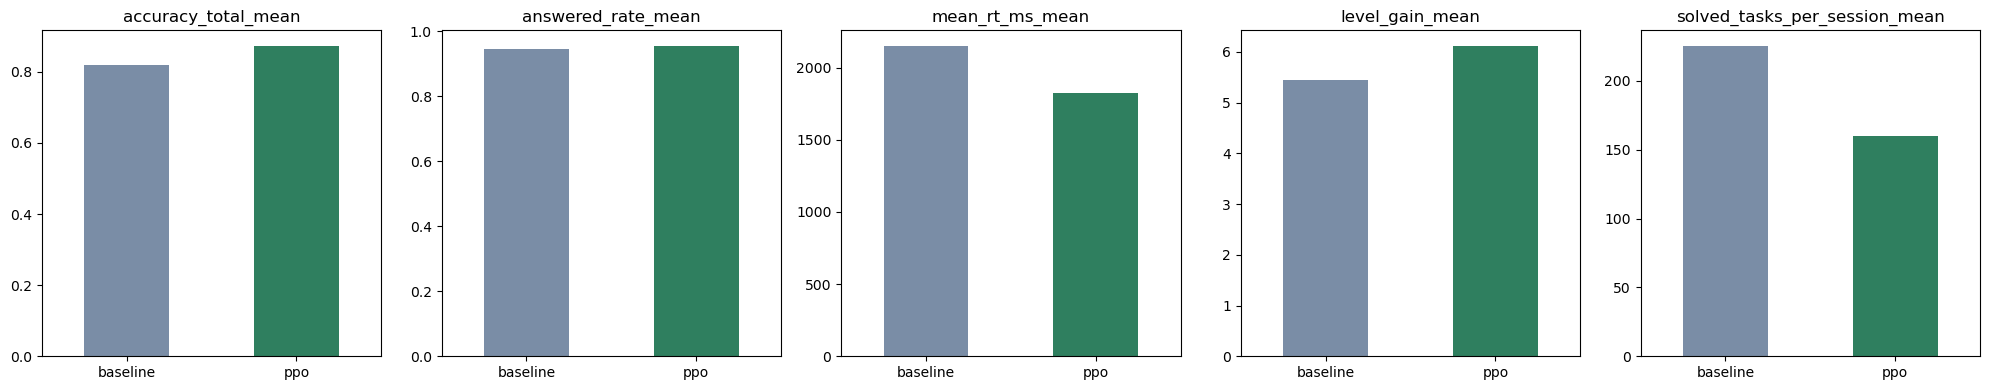

In [16]:
plot_columns = [
    'accuracy_total_mean',
    'answered_rate_mean',
    'mean_rt_ms_mean',
    'level_gain_mean',
    'solved_tasks_per_session_mean',
]

fig, axes = plt.subplots(1, len(plot_columns), figsize=(20, 4))
for ax, column in zip(axes, plot_columns):
    participant_mode_summary.plot(
        x='mode',
        y=column,
        kind='bar',
        legend=False,
        ax=ax,
        color=['#7a8da6', '#2f7f5f'],
    )
    ax.set_title(column)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
plt.tight_layout()


## 8. Индивидуальные различия между режимами


In [17]:
paired_accuracy = participant_mode_df.pivot_table(index='participant_id', columns='mode', values='accuracy_total', aggfunc='mean')
paired_rt = participant_mode_df.pivot_table(index='participant_id', columns='mode', values='mean_rt_ms', aggfunc='mean')
paired_solved = participant_mode_df.pivot_table(index='participant_id', columns='mode', values='solved_tasks_per_session', aggfunc='mean')
paired_answered = participant_mode_df.pivot_table(index='participant_id', columns='mode', values='answered_rate', aggfunc='mean')
paired_level = participant_mode_df.pivot_table(index='participant_id', columns='mode', values='level_gain_mean', aggfunc='mean')

paired_table = pd.DataFrame(index=participant_mode_df['participant_id'].unique())
if {'baseline', 'ppo'}.issubset(paired_accuracy.columns):
    paired_table['accuracy_delta_model_minus_baseline'] = paired_accuracy['ppo'] - paired_accuracy['baseline']
if {'baseline', 'ppo'}.issubset(paired_rt.columns):
    paired_table['rt_delta_model_minus_baseline'] = paired_rt['ppo'] - paired_rt['baseline']
if {'baseline', 'ppo'}.issubset(paired_solved.columns):
    paired_table['solved_delta_model_minus_baseline'] = paired_solved['ppo'] - paired_solved['baseline']
if {'baseline', 'ppo'}.issubset(paired_answered.columns):
    paired_table['answered_rate_delta_model_minus_baseline'] = paired_answered['ppo'] - paired_answered['baseline']
if {'baseline', 'ppo'}.issubset(paired_level.columns):
    paired_table['level_gain_delta_model_minus_baseline'] = paired_level['ppo'] - paired_level['baseline']

paired_table = paired_table.dropna(how='all')
paired_table


,accuracy_delta_model_minus_baseline,rt_delta_model_minus_baseline,solved_delta_model_minus_baseline,answered_rate_delta_model_minus_baseline,level_gain_delta_model_minus_baseline
participant_01,-0.519364,496.386276,-56.454545,-0.640133,-3.454545
participant_02,0.062457,332.606970,200.666667,0.027171,-0.500000
participant_03,0.032389,-348.440078,157.666667,0.025416,5.666667
participant_04,0.029751,-397.117968,88.000000,0.025268,0.000000
participant_05,0.102480,-234.839460,-32.000000,0.073385,5.500000
participant_07,0.051296,-155.260688,-156.000000,0.009674,0.000000
participant_08,0.022841,-184.336537,-439.500000,0.013981,-5.000000
participant_09,0.081076,-322.714241,-240.000000,0.075521,-1.000000
participant_10,0.246667,-603.422222,-39.500000,0.100000,-0.500000
participant_12,0.097449,-576.510015,-51.000000,0.027211,0.000000


In [18]:
if not paired_table.empty:
    total_pairs = len(paired_table)
    if 'accuracy_delta_model_minus_baseline' in paired_table:
        acc_positive = int((paired_table['accuracy_delta_model_minus_baseline'] > 0).sum())
        print(f'- У {acc_positive} из {total_pairs} участников модельный режим дал прирост точности.')
    if 'rt_delta_model_minus_baseline' in paired_table:
        rt_positive = int((paired_table['rt_delta_model_minus_baseline'] < 0).sum())
        print(f'- У {rt_positive} из {total_pairs} участников модельный режим сократил среднее время ответа.')
    if 'solved_delta_model_minus_baseline' in paired_table:
        solved_positive = int((paired_table['solved_delta_model_minus_baseline'] > 0).sum())
        print(f'- У {solved_positive} из {total_pairs} участников модельный режим увеличил число успешно решённых задач на сессию.')
    if 'answered_rate_delta_model_minus_baseline' in paired_table:
        answered_positive = int((paired_table['answered_rate_delta_model_minus_baseline'] > 0).sum())
        print(f'- У {answered_positive} из {total_pairs} участников модельный режим повысил долю задач с ответом.')


- У 18 из 19 участников модельный режим дал прирост точности.
- У 17 из 19 участников модельный режим сократил среднее время ответа.
- У 9 из 19 участников модельный режим увеличил число успешно решённых задач на сессию.
- У 18 из 19 участников модельный режим повысил долю задач с ответом.


## 9. Баланс выигрышей и проигрышей модели

In [19]:
win_balance_rows = []
for column, better_when in [
    ('accuracy_delta_model_minus_baseline', 'positive'),
    ('answered_rate_delta_model_minus_baseline', 'positive'),
    ('solved_delta_model_minus_baseline', 'positive'),
    ('rt_delta_model_minus_baseline', 'negative'),
]:
    if column in paired_table.columns:
        series = paired_table[column].dropna()
        if better_when == 'positive':
            wins = int((series > 0).sum())
            losses = int((series < 0).sum())
        else:
            wins = int((series < 0).sum())
            losses = int((series > 0).sum())
        ties = int((series == 0).sum())
        win_balance_rows.append({
            'metric': column,
            'wins_for_model': wins,
            'losses_for_model': losses,
            'ties': ties,
            'share_of_wins_pct': wins / len(series) * 100 if len(series) else np.nan,
        })

win_balance_df = pd.DataFrame(win_balance_rows)
win_balance_df


,metric,wins_for_model,losses_for_model,ties,share_of_wins_pct
0,accuracy_delta_model_minus_baseline,18,1,0,94.736842
1,answered_rate_delta_model_minus_baseline,18,1,0,94.736842
2,solved_delta_model_minus_baseline,9,10,0,47.368421
3,rt_delta_model_minus_baseline,17,2,0,89.473684


In [20]:
if not win_balance_df.empty:
    for _, row in win_balance_df.iterrows():
        print(f"- Для {row['metric']} модель выигрывает у {row['wins_for_model']} участников, проигрывает у {row['losses_for_model']}, без изменений у {row['ties']}. Доля выигрышей модели: {row['share_of_wins_pct']:.1f}%.")


- Для accuracy_delta_model_minus_baseline модель выигрывает у 18 участников, проигрывает у 1, без изменений у 0. Доля выигрышей модели: 94.7%.
- Для answered_rate_delta_model_minus_baseline модель выигрывает у 18 участников, проигрывает у 1, без изменений у 0. Доля выигрышей модели: 94.7%.
- Для solved_delta_model_minus_baseline модель выигрывает у 9 участников, проигрывает у 10, без изменений у 0. Доля выигрышей модели: 47.4%.
- Для rt_delta_model_minus_baseline модель выигрывает у 17 участников, проигрывает у 2, без изменений у 0. Доля выигрышей модели: 89.5%.


## 10. Статистические тесты

- `permutation test` для независимых выборок: различаются ли распределения baseline и ppo на уровне всех сессий;
- `sign-flip test` для парных сравнений: проявляется ли различие у тех же самых участников.


In [21]:
unpaired_tests = pd.DataFrame(
    [
        {'metric': 'accuracy_total', **nu.unpaired_permutation_test(session_df.loc[session_df['mode'] == 'baseline', 'accuracy_total'], session_df.loc[session_df['mode'] == 'ppo', 'accuracy_total'], higher_is_better=True)},
        {'metric': 'answered_rate', **nu.unpaired_permutation_test(session_df.loc[session_df['mode'] == 'baseline', 'answered_rate'], session_df.loc[session_df['mode'] == 'ppo', 'answered_rate'], higher_is_better=True)},
        {'metric': 'mean_rt_ms', **nu.unpaired_permutation_test(session_df.loc[session_df['mode'] == 'baseline', 'mean_rt_ms'], session_df.loc[session_df['mode'] == 'ppo', 'mean_rt_ms'], higher_is_better=False)},
        {'metric': 'level_gain', **nu.unpaired_permutation_test(session_df.loc[session_df['mode'] == 'baseline', 'level_gain'], session_df.loc[session_df['mode'] == 'ppo', 'level_gain'], higher_is_better=True)},
        {'metric': 'solved_tasks', **nu.unpaired_permutation_test(session_df.loc[session_df['mode'] == 'baseline', 'solved_tasks'], session_df.loc[session_df['mode'] == 'ppo', 'solved_tasks'], higher_is_better=True)},
    ]
)
unpaired_tests


,metric,baseline_mean,model_mean,delta,p_value
0,accuracy_total,0.690353,0.861733,0.171380,0.004199
1,answered_rate,0.811905,0.964760,0.152854,0.008398
2,mean_rt_ms,2009.029772,1811.253812,-197.775960,0.051190
3,level_gain,4.340426,5.285714,0.945289,0.181564
4,solved_tasks,151.127660,165.285714,14.158055,0.387123


In [22]:
paired_tests = pd.DataFrame(
    [
        {'metric': 'accuracy_total', **nu.paired_signflip_test(participant_mode_df, 'accuracy_total', higher_is_better=True)},
        {'metric': 'answered_rate', **nu.paired_signflip_test(participant_mode_df, 'answered_rate', higher_is_better=True)},
        {'metric': 'mean_rt_ms', **nu.paired_signflip_test(participant_mode_df, 'mean_rt_ms', higher_is_better=False)},
        {'metric': 'level_gain_mean', **nu.paired_signflip_test(participant_mode_df, 'level_gain_mean', higher_is_better=True)},
        {'metric': 'solved_tasks_per_session', **nu.paired_signflip_test(participant_mode_df, 'solved_tasks_per_session', higher_is_better=True)},
    ]
)
paired_tests


,metric,pairs,baseline_mean,model_mean,delta,p_value
0,accuracy_total,19,0.817874,0.872988,0.055113,0.064187
1,answered_rate,19,0.944808,0.954821,0.010013,0.486303
2,mean_rt_ms,19,2150.486223,1825.621247,-324.864977,0.001200
3,level_gain_mean,19,5.438836,6.118421,0.679585,0.246951
4,solved_tasks_per_session,19,225.351116,160.061404,-65.289713,0.890222


In [23]:
sig_unpaired = unpaired_tests[unpaired_tests['p_value'] < 0.05]['metric'].tolist()
sig_paired = paired_tests[paired_tests['p_value'] < 0.05]['metric'].tolist()
print(f'- На уровне независимых выборок статистически значимыми оказались: {sig_unpaired if sig_unpaired else "значимых различий не найдено"}.')
print(f'- На уровне парных сравнений статистически значимыми оказались: {sig_paired if sig_paired else "значимых различий не найдено"}.')


- На уровне независимых выборок статистически значимыми оказались: ['accuracy_total', 'answered_rate'].
- На уровне парных сравнений статистически значимыми оказались: ['mean_rt_ms'].


## 11. Bootstrap-оценка неопределённости

Доверительные интервалы для разницы средних между режимами.

Если доверительный интервал не пересекает ноль, это поддерживает наличие устойчивого различия между режимами.
Если интервал широкий, это означает повышенную неопределённость и необходимость аккуратной интерпретации результата.



In [24]:
def bootstrap_difference(series_a, series_b, n_boot=5000, seed=42):
    a = pd.Series(series_a).dropna().astype(float).to_numpy()
    b = pd.Series(series_b).dropna().astype(float).to_numpy()
    if len(a) == 0 or len(b) == 0:
        return np.nan, np.nan, np.nan
    rng = np.random.default_rng(seed)
    diffs = []
    for _ in range(n_boot):
        sample_a = rng.choice(a, size=len(a), replace=True)
        sample_b = rng.choice(b, size=len(b), replace=True)
        diffs.append(sample_b.mean() - sample_a.mean())
    diffs = np.array(diffs)
    return diffs.mean(), np.quantile(diffs, 0.025), np.quantile(diffs, 0.975)

bootstrap_rows = []
for metric in [
    'accuracy_total',
    'answered_rate',
    'mean_rt_ms',
    'level_gain',
    'solved_tasks',
]:
    mean_diff, ci_low, ci_high = bootstrap_difference(
        session_df.loc[session_df['mode'] == 'baseline', metric],
        session_df.loc[session_df['mode'] == 'ppo', metric],
    )
    bootstrap_rows.append(
        {
            'metric': metric,
            'mean_delta_model_minus_baseline': mean_diff,
            'ci_2_5': ci_low,
            'ci_97_5': ci_high,
        }
    )

bootstrap_df = pd.DataFrame(bootstrap_rows)
bootstrap_df


,metric,mean_delta_model_minus_baseline,ci_2_5,ci_97_5
0,accuracy_total,0.171514,0.055122,0.281594
1,answered_rate,0.152284,0.050800,0.258001
2,mean_rt_ms,-199.191083,-409.282375,-2.302084
3,level_gain,0.962068,-0.922492,2.829122
4,solved_tasks,14.377186,-80.213982,115.054046


In [25]:
for _, row in bootstrap_df.iterrows():
    print(f"- Для {row['metric']} bootstrap-оценка разницы средних составляет {row['mean_delta_model_minus_baseline']:.4f}, 95%-й интервал: [{row['ci_2_5']:.4f}; {row['ci_97_5']:.4f}].")



- Для accuracy_total bootstrap-оценка разницы средних составляет 0.1715, 95%-й интервал: [0.0551; 0.2816].
- Для answered_rate bootstrap-оценка разницы средних составляет 0.1523, 95%-й интервал: [0.0508; 0.2580].
- Для mean_rt_ms bootstrap-оценка разницы средних составляет -199.1911, 95%-й интервал: [-409.2824; -2.3021].
- Для level_gain bootstrap-оценка разницы средних составляет 0.9621, 95%-й интервал: [-0.9225; 2.8291].
- Для solved_tasks bootstrap-оценка разницы средних составляет 14.3772, 95%-й интервал: [-80.2140; 115.0540].


## 12. Сравнение по возрастным группам

In [26]:
age_summary = (
    participant_mode_df
    .groupby(['age_group', 'mode'], dropna=False)
    .agg(
        participants=('participant_id', 'nunique'),
        accuracy_total=('accuracy_total', 'mean'),
        answered_rate=('answered_rate', 'mean'),
        mean_rt_ms=('mean_rt_ms', 'mean'),
        solved_tasks_per_session=('solved_tasks_per_session', 'mean'),
        level_gain_mean=('level_gain_mean', 'mean'),
    )
    .reset_index()
)
age_summary


,age_group,mode,participants,accuracy_total,answered_rate,mean_rt_ms,solved_tasks_per_session,level_gain_mean
0,21-24,baseline,3,0.775460,0.927182,2268.427117,316.266667,3.600000
1,21-24,ppo,3,0.863650,0.985971,1786.893667,123.222222,4.333333
2,25-28,baseline,9,0.828488,0.943380,2064.136695,197.865320,6.143098
3,25-28,ppo,9,0.839852,0.912968,1793.035405,157.333333,7.666667
4,29-34,baseline,4,0.832848,0.972951,2229.923820,302.645833,6.312500
5,29-34,ppo,4,0.910478,0.993305,1942.027698,281.250000,6.375000
6,35-39,baseline,3,0.808485,0.929192,2185.677120,113.833333,4.000000
7,35-39,ppo,3,0.931746,0.997917,1806.897751,43.500000,2.916667


In [27]:
for group in sorted(age_summary['age_group'].dropna().unique()):
    sub = age_summary[age_summary['age_group'] == group]
    if {'baseline', 'ppo'}.issubset(set(sub['mode'])):
        b = sub.set_index('mode').loc['baseline']
        p = sub.set_index('mode').loc['ppo']
        print(f"- Группа {group}: точность baseline = {b['accuracy_total']:.3f}, ppo = {p['accuracy_total']:.3f}; answered_rate baseline = {b['answered_rate']:.3f}, ppo = {p['answered_rate']:.3f}; mean RT baseline = {b['mean_rt_ms']:.1f} мс, ppo = {p['mean_rt_ms']:.1f} мс.")

- Группа 21-24: точность baseline = 0.775, ppo = 0.864; answered_rate baseline = 0.927, ppo = 0.986; mean RT baseline = 2268.4 мс, ppo = 1786.9 мс.
- Группа 25-28: точность baseline = 0.828, ppo = 0.840; answered_rate baseline = 0.943, ppo = 0.913; mean RT baseline = 2064.1 мс, ppo = 1793.0 мс.
- Группа 29-34: точность baseline = 0.833, ppo = 0.910; answered_rate baseline = 0.973, ppo = 0.993; mean RT baseline = 2229.9 мс, ppo = 1942.0 мс.
- Группа 35-39: точность baseline = 0.808, ppo = 0.932; answered_rate baseline = 0.929, ppo = 0.998; mean RT baseline = 2185.7 мс, ppo = 1806.9 мс.


## 13. Сравнение по полу

In [28]:
gender_summary = (
    session_df
    .groupby(['gender', 'mode'], dropna=False)
    .agg(
        sessions=('session_id', 'nunique'),
        accuracy_total=('accuracy_total', 'mean'),
        answered_rate=('answered_rate', 'mean'),
        mean_rt_ms=('mean_rt_ms', 'mean'),
        solved_tasks=('solved_tasks', 'mean'),
    )
    .reset_index()
)
gender_summary


,gender,mode,sessions,accuracy_total,answered_rate,mean_rt_ms,solved_tasks
0,female,baseline,20,0.699977,0.825602,1774.995782,113.550000
1,female,ppo,7,0.812293,0.888783,1836.722024,137.285714
2,male,baseline,27,0.683225,0.801760,2192.186807,178.962963
3,male,ppo,21,0.878213,0.990085,1802.764408,174.619048


In [29]:
for gender in gender_summary['gender'].dropna().unique():
    sub = gender_summary[gender_summary['gender'] == gender]
    if {'baseline', 'ppo'}.issubset(set(sub['mode'])):
        b = sub.set_index('mode').loc['baseline']
        p = sub.set_index('mode').loc['ppo']
        print(f"- Для группы {gender}: точность baseline = {b['accuracy_total']:.3f}, ppo = {p['accuracy_total']:.3f}; answered_rate baseline = {b['answered_rate']:.3f}, ppo = {p['answered_rate']:.3f}; mean RT baseline = {b['mean_rt_ms']:.1f} мс, ppo = {p['mean_rt_ms']:.1f} мс.")


- Для группы female: точность baseline = 0.700, ppo = 0.812; answered_rate baseline = 0.826, ppo = 0.889; mean RT baseline = 1775.0 мс, ppo = 1836.7 мс.
- Для группы male: точность baseline = 0.683, ppo = 0.878; answered_rate baseline = 0.802, ppo = 0.990; mean RT baseline = 2192.2 мс, ppo = 1802.8 мс.


## 14. Сравнение по типам задач

Как выражен эффект модельной адаптации для разных мини-игр. 


In [30]:
task_summary = nu.task_mode_summary(task_df)
task_summary


,mode,task_id,rows,accuracy_total,answered_rate,solved_rate,mean_rt_ms,median_rt_ms
0,baseline,radar_scan,1458,0.853224,0.946502,0.853224,1880.552899,1757.0
1,baseline,sequence_memory,1663,0.775105,0.961515,0.775105,3239.385866,3209.0
2,baseline,rule_switch,1732,0.915127,0.965935,0.915127,1452.912134,1260.0
3,baseline,compare_codes,1984,0.870464,0.967238,0.870464,1657.047942,1524.0
4,baseline,parity_check,1547,0.813187,0.953458,0.813187,1674.700339,1530.0
5,ppo,compare_codes,1217,0.917009,0.983566,0.917009,1461.826232,1383.0
6,ppo,radar_scan,886,0.949210,0.987585,0.949210,1551.284571,1478.0
7,ppo,parity_check,926,0.877970,0.977322,0.877970,1512.409945,1416.0
8,ppo,rule_switch,1037,0.950820,0.985535,0.950820,1249.159491,1130.5
9,ppo,sequence_memory,989,0.881699,0.996967,0.881699,3070.856998,3044.5


In [31]:
task_delta = task_summary.pivot(index='task_id', columns='mode', values=['accuracy_total', 'answered_rate', 'mean_rt_ms'])
task_delta.columns = ['_'.join(col).strip() for col in task_delta.columns.to_flat_index()]
if {'accuracy_total_baseline', 'accuracy_total_ppo'}.issubset(task_delta.columns):
    task_delta['accuracy_delta_model_minus_baseline'] = task_delta['accuracy_total_ppo'] - task_delta['accuracy_total_baseline']
if {'answered_rate_baseline', 'answered_rate_ppo'}.issubset(task_delta.columns):
    task_delta['answered_delta_model_minus_baseline'] = task_delta['answered_rate_ppo'] - task_delta['answered_rate_baseline']
if {'mean_rt_ms_baseline', 'mean_rt_ms_ppo'}.issubset(task_delta.columns):
    task_delta['rt_delta_model_minus_baseline'] = task_delta['mean_rt_ms_ppo'] - task_delta['mean_rt_ms_baseline']
task_delta = task_delta.reset_index()
task_delta


,task_id,accuracy_total_baseline,accuracy_total_ppo,answered_rate_baseline,answered_rate_ppo,mean_rt_ms_baseline,mean_rt_ms_ppo,accuracy_delta_model_minus_baseline,answered_delta_model_minus_baseline,rt_delta_model_minus_baseline
0,compare_codes,0.870464,0.917009,0.967238,0.983566,1657.047942,1461.826232,0.046545,0.016328,-195.221709
1,parity_check,0.813187,0.877970,0.953458,0.977322,1674.700339,1512.409945,0.064783,0.023864,-162.290394
2,radar_scan,0.853224,0.949210,0.946502,0.987585,1880.552899,1551.284571,0.095986,0.041083,-329.268327
3,rule_switch,0.915127,0.950820,0.965935,0.985535,1452.912134,1249.159491,0.035693,0.019600,-203.752643
4,sequence_memory,0.775105,0.881699,0.961515,0.996967,3239.385866,3070.856998,0.106593,0.035451,-168.528868


In [32]:
if 'accuracy_delta_model_minus_baseline' in task_delta.columns:
    top_accuracy = task_delta.sort_values('accuracy_delta_model_minus_baseline', ascending=False)[['task_id', 'accuracy_delta_model_minus_baseline']].head(3)
    print('- Наибольший прирост точности в ppo наблюдается для следующих задач:')
    print(top_accuracy.to_string(index=False))
if 'answered_delta_model_minus_baseline' in task_delta.columns:
    top_answered = task_delta.sort_values('answered_delta_model_minus_baseline', ascending=False)[['task_id', 'answered_delta_model_minus_baseline']].head(3)
    print('- Наибольший прирост доли ответов в ppo наблюдается для следующих задач:')
    print(top_answered.to_string(index=False))


- Наибольший прирост точности в ppo наблюдается для следующих задач:
        task_id  accuracy_delta_model_minus_baseline
sequence_memory                             0.106593
     radar_scan                             0.095986
   parity_check                             0.064783
- Наибольший прирост доли ответов в ppo наблюдается для следующих задач:
        task_id  answered_delta_model_minus_baseline
     radar_scan                             0.041083
sequence_memory                             0.035451
   parity_check                             0.023864


## 15. Графики для текста раздела 5.1

- распределение длины сессий;
- сравнение `accuracy_total`, `answered_rate` и `mean_rt_ms`;
- нормализованные показатели эффективности;
- bootstrap-распределения разницы метрик между режимами;
- распределение выигрышей модели по пользователям.


In [33]:
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    pass

plt.rcParams.update({
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

MODE_ORDER = ['baseline', 'ppo']
MODE_LABELS = {
    'baseline': 'Базовый режим',
    'ppo': 'Модельный режим',
}
MODE_COLORS = {
    'baseline': '#8FA3B8',
    'ppo': '#2F7F5F',
}

if 'normalized_summary' not in globals():
    normalized_summary = participant_mode_df.groupby('mode', as_index=False).agg(
        participants=('participant_id', 'nunique'),
        total_tasks=('total_tasks', 'sum'),
        answered_tasks=('answered_tasks', 'sum'),
        solved_tasks=('solved_tasks', 'sum'),
        mean_rt_ms=('mean_rt_ms', 'mean'),
        accuracy_total=('accuracy_total', 'mean'),
        answered_rate=('answered_rate', 'mean'),
    )
    baseline_row = normalized_summary.set_index('mode').loc['baseline']
    normalized_summary['solved_per_100_tasks'] = normalized_summary['solved_tasks'] / normalized_summary['total_tasks'] * 100
    normalized_summary['answered_per_100_tasks'] = normalized_summary['answered_tasks'] / normalized_summary['total_tasks'] * 100
    normalized_summary['relative_accuracy_to_baseline_pct'] = (normalized_summary['accuracy_total'] / baseline_row['accuracy_total'] - 1) * 100
    normalized_summary['relative_rt_to_baseline_pct'] = (normalized_summary['mean_rt_ms'] / baseline_row['mean_rt_ms'] - 1) * 100

if 'paired_table' not in globals():
    paired_accuracy = participant_mode_df.pivot_table(index='participant_id', columns='mode', values='accuracy_total', aggfunc='mean')
    paired_rt = participant_mode_df.pivot_table(index='participant_id', columns='mode', values='mean_rt_ms', aggfunc='mean')
    paired_solved = participant_mode_df.pivot_table(index='participant_id', columns='mode', values='solved_tasks_per_session', aggfunc='mean')
    paired_answered = participant_mode_df.pivot_table(index='participant_id', columns='mode', values='answered_rate', aggfunc='mean')
    paired_level = participant_mode_df.pivot_table(index='participant_id', columns='mode', values='level_gain_mean', aggfunc='mean')

    paired_table = pd.DataFrame(index=participant_mode_df['participant_id'].unique())
    if {'baseline', 'ppo'}.issubset(paired_accuracy.columns):
        paired_table['accuracy_delta_model_minus_baseline'] = paired_accuracy['ppo'] - paired_accuracy['baseline']
    if {'baseline', 'ppo'}.issubset(paired_rt.columns):
        paired_table['rt_delta_model_minus_baseline'] = paired_rt['ppo'] - paired_rt['baseline']
    if {'baseline', 'ppo'}.issubset(paired_solved.columns):
        paired_table['solved_delta_model_minus_baseline'] = paired_solved['ppo'] - paired_solved['baseline']
    if {'baseline', 'ppo'}.issubset(paired_answered.columns):
        paired_table['answered_rate_delta_model_minus_baseline'] = paired_answered['ppo'] - paired_answered['baseline']
    if {'baseline', 'ppo'}.issubset(paired_level.columns):
        paired_table['level_gain_delta_model_minus_baseline'] = paired_level['ppo'] - paired_level['baseline']
    paired_table = paired_table.dropna(how='all')


def _annotate_bars(ax, decimals=1, suffix=''):
    for patch in ax.patches:
        height = patch.get_height()
        if pd.isna(height):
            continue
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            height + max(abs(height) * 0.01, 0.5),
            f'{height:.{decimals}f}{suffix}',
            ha='center',
            va='bottom',
            fontsize=9,
            color='#222222',
        )


def _draw_mode_boxplot(ax, df, metric, title, ylabel):
    values_by_mode = [df.loc[df['mode'] == mode, metric].dropna().to_numpy() for mode in MODE_ORDER]
    box = ax.boxplot(
        values_by_mode,
        positions=np.arange(1, len(MODE_ORDER) + 1),
        widths=0.55,
        patch_artist=True,
        showfliers=False,
    )
    for patch, mode in zip(box['boxes'], MODE_ORDER):
        patch.set_facecolor(MODE_COLORS[mode])
        patch.set_alpha(0.55)
        patch.set_edgecolor('#263238')
    for median in box['medians']:
        median.set_color('#111111')
        median.set_linewidth(2)

    for idx, mode in enumerate(MODE_ORDER, start=1):
        values = df.loc[df['mode'] == mode, metric].dropna().to_numpy()
        rng = np.random.default_rng(100 + idx)
        jitter = rng.normal(0, 0.045, size=len(values))
        ax.scatter(
            np.full(len(values), idx) + jitter,
            values,
            s=18,
            alpha=0.28,
            color=MODE_COLORS[mode],
            edgecolors='none',
            zorder=2,
        )
        if len(values):
            ax.scatter([idx], [values.mean()], s=75, marker='D', color='#111111', zorder=4)

    ax.set_xticks(range(1, len(MODE_ORDER) + 1), [MODE_LABELS[mode] for mode in MODE_ORDER])
    ax.set_title(title)
    ax.set_ylabel(ylabel)


def _bootstrap_differences(series_a, series_b, n_boot=5000, seed=42):
    a = pd.Series(series_a).dropna().astype(float).to_numpy()
    b = pd.Series(series_b).dropna().astype(float).to_numpy()
    rng = np.random.default_rng(seed)
    diffs = []
    for _ in range(n_boot):
        sample_a = rng.choice(a, size=len(a), replace=True)
        sample_b = rng.choice(b, size=len(b), replace=True)
        diffs.append(sample_b.mean() - sample_a.mean())
    return np.array(diffs)


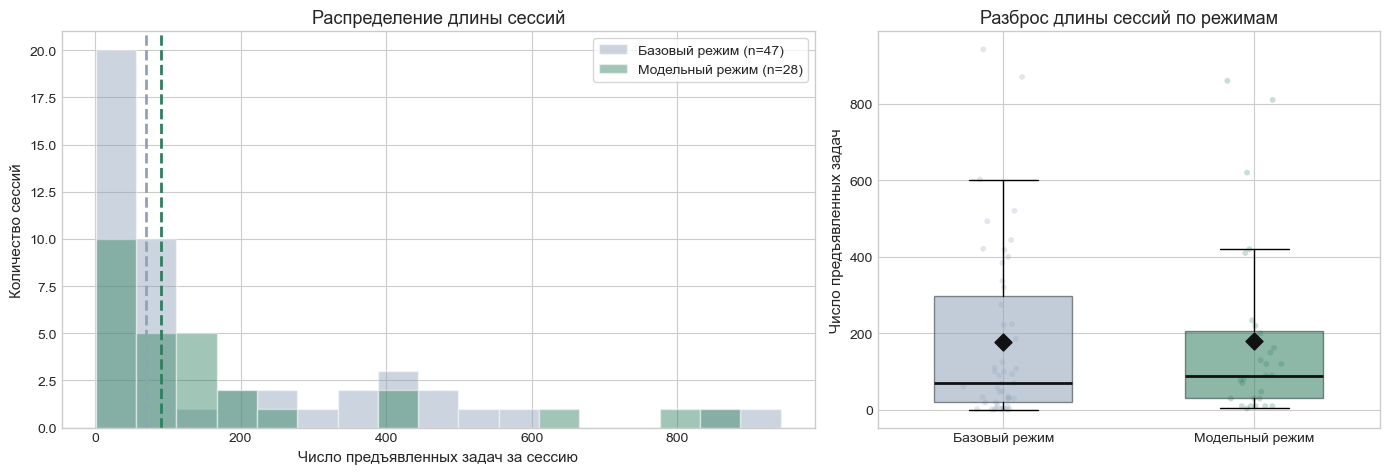

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [1.5, 1]})
all_lengths = session_df['total_tasks'].dropna()
bins = np.linspace(all_lengths.min(), all_lengths.max(), 18)

for mode in MODE_ORDER:
    values = session_df.loc[session_df['mode'] == mode, 'total_tasks'].dropna()
    axes[0].hist(
        values,
        bins=bins,
        alpha=0.45,
        color=MODE_COLORS[mode],
        edgecolor='white',
        label=f"{MODE_LABELS[mode]} (n={len(values)})",
    )
    axes[0].axvline(values.median(), color=MODE_COLORS[mode], linestyle='--', linewidth=2)

axes[0].set_title('Распределение длины сессий')
axes[0].set_xlabel('Число предъявленных задач за сессию')
axes[0].set_ylabel('Количество сессий')
axes[0].legend(frameon=True)

length_values = [session_df.loc[session_df['mode'] == mode, 'total_tasks'].dropna().to_numpy() for mode in MODE_ORDER]
box = axes[1].boxplot(length_values, widths=0.55, patch_artist=True, showfliers=False)
for patch, mode in zip(box['boxes'], MODE_ORDER):
    patch.set_facecolor(MODE_COLORS[mode])
    patch.set_alpha(0.55)
    patch.set_edgecolor('#263238')
for median in box['medians']:
    median.set_color('#111111')
    median.set_linewidth(2)

for idx, values in enumerate(length_values, start=1):
    rng = np.random.default_rng(300 + idx)
    jitter = rng.normal(0, 0.045, size=len(values))
    axes[1].scatter(np.full(len(values), idx) + jitter, values, s=18, alpha=0.25, color=MODE_COLORS[MODE_ORDER[idx - 1]], edgecolors='none')
    axes[1].scatter([idx], [values.mean()], s=75, marker='D', color='#111111', zorder=4)

axes[1].set_xticks([1, 2], [MODE_LABELS[mode] for mode in MODE_ORDER])
axes[1].set_ylabel('Число предъявленных задач')
axes[1].set_title('Разброс длины сессий по режимам')

plt.suptitle('')
plt.tight_layout()
plt.show()


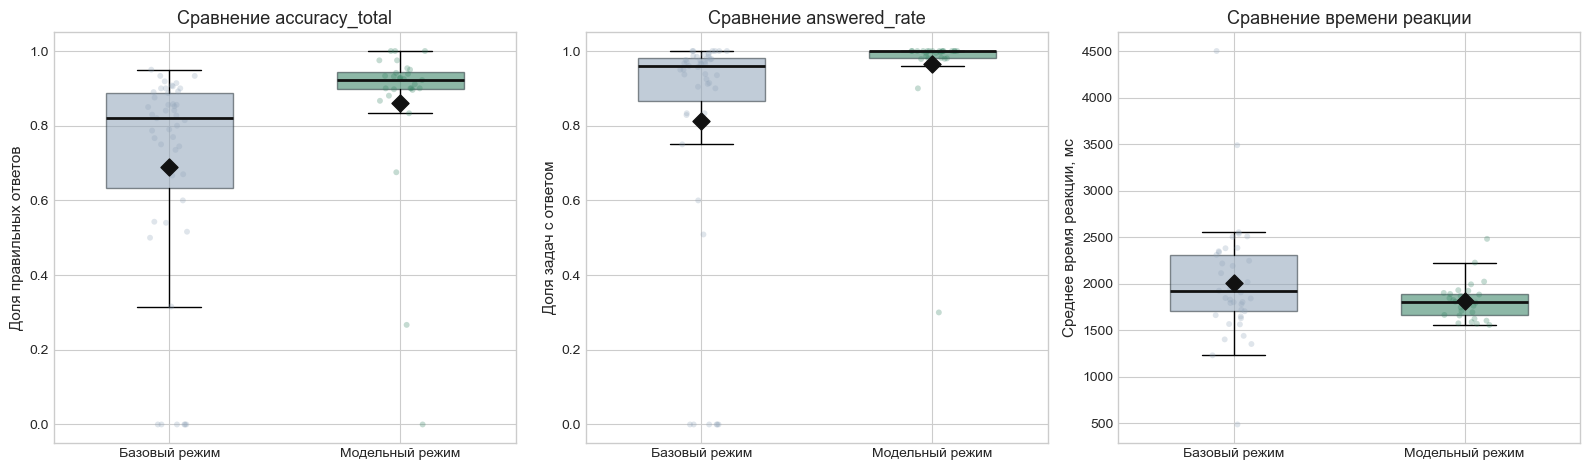

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8))
metric_specs = [
    ('accuracy_total', 'Сравнение accuracy_total', 'Доля правильных ответов'),
    ('answered_rate', 'Сравнение answered_rate', 'Доля задач с ответом'),
    ('mean_rt_ms', 'Сравнение времени реакции', 'Среднее время реакции, мс'),
]

for ax, (metric, title, ylabel) in zip(axes, metric_specs):
    _draw_mode_boxplot(ax, session_df, metric, title, ylabel)

plt.tight_layout()
plt.show()


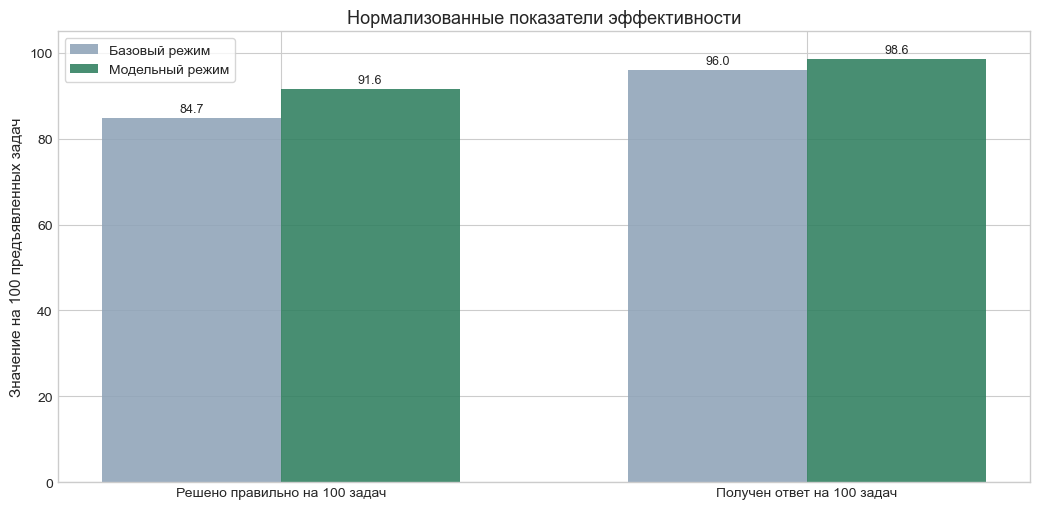

In [36]:
norm_metrics = [
    ('solved_per_100_tasks', 'Решено правильно на 100 задач'),
    ('answered_per_100_tasks', 'Получен ответ на 100 задач'),
]

x = np.arange(len(norm_metrics))
width = 0.34
fig, ax = plt.subplots(figsize=(10.5, 5.2))
summary_by_mode = normalized_summary.set_index('mode')

for idx, mode in enumerate(MODE_ORDER):
    values = [summary_by_mode.loc[mode, metric] for metric, _ in norm_metrics]
    bars = ax.bar(
        x + (idx - 0.5) * width,
        values,
        width=width,
        color=MODE_COLORS[mode],
        alpha=0.88,
        label=MODE_LABELS[mode],
    )
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.7,
            f"{bar.get_height():.1f}",
            ha='center',
            va='bottom',
            fontsize=9,
        )

ax.set_xticks(x, [label for _, label in norm_metrics])
ax.set_ylim(0, 105)
ax.set_ylabel('Значение на 100 предъявленных задач')
ax.set_title('Нормализованные показатели эффективности')
ax.legend(frameon=True)
plt.tight_layout()
plt.show()


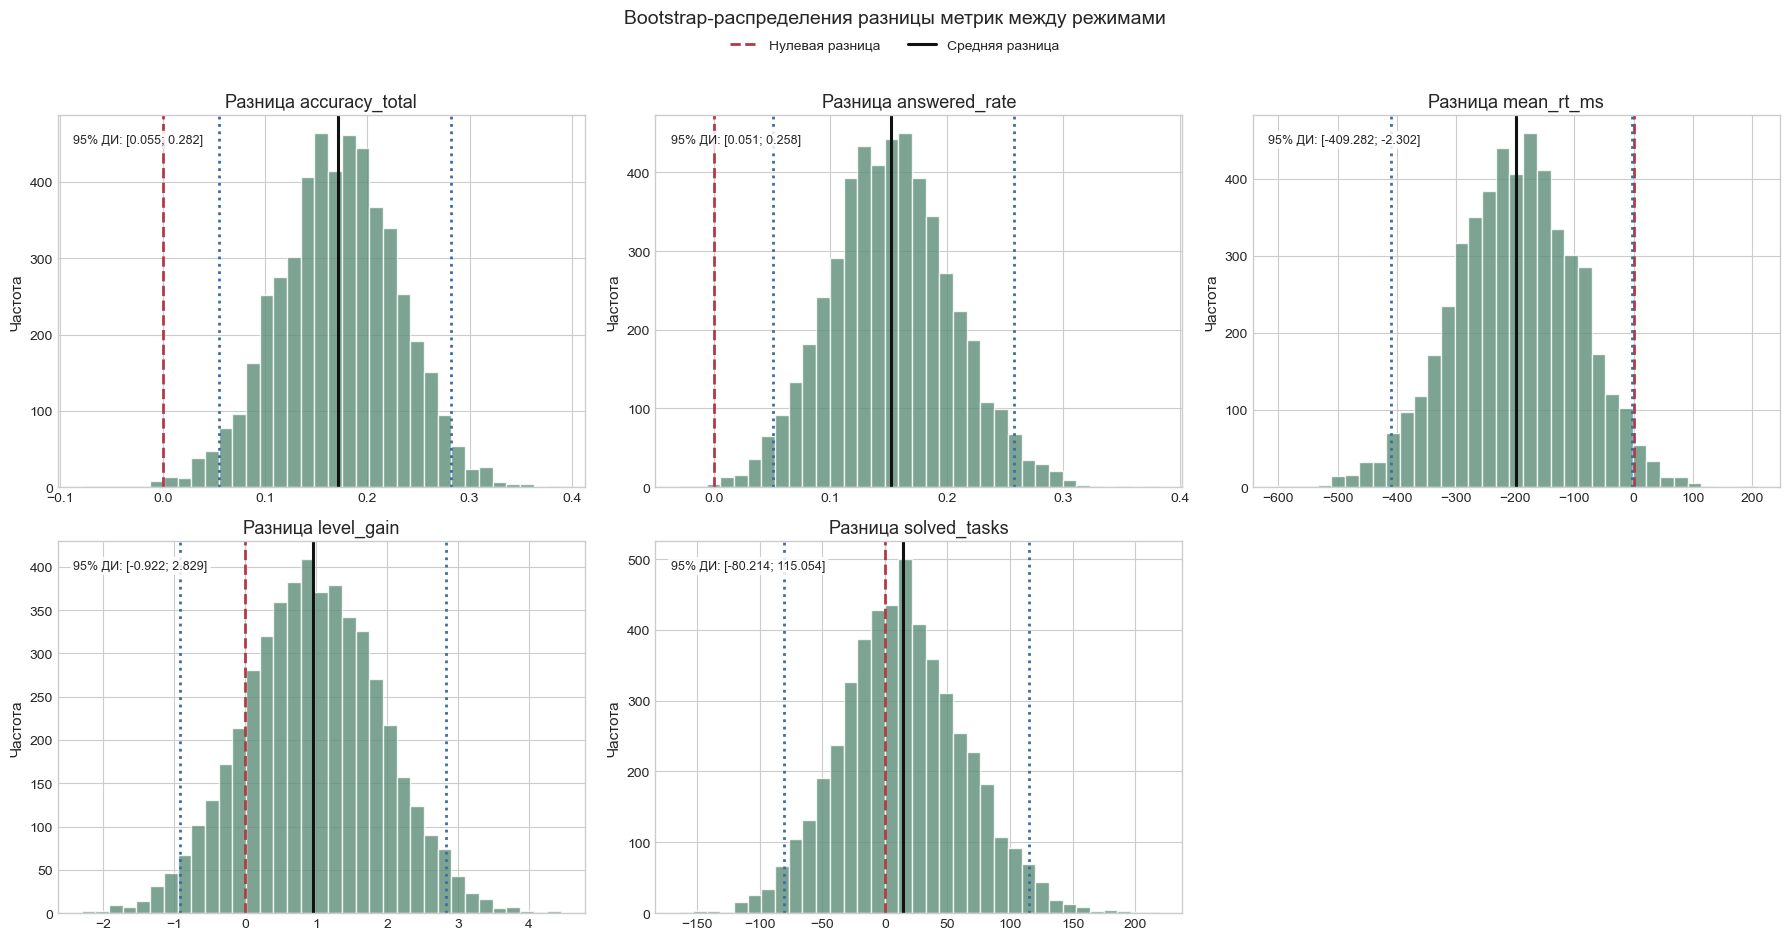

In [37]:
bootstrap_specs = [
    ('accuracy_total', 'Разница accuracy_total'),
    ('answered_rate', 'Разница answered_rate'),
    ('mean_rt_ms', 'Разница mean_rt_ms'),
    ('level_gain', 'Разница level_gain'),
    ('solved_tasks', 'Разница solved_tasks'),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.flatten()

for ax, (metric, title) in zip(axes, bootstrap_specs):
    diffs = _bootstrap_differences(
        session_df.loc[session_df['mode'] == 'baseline', metric],
        session_df.loc[session_df['mode'] == 'ppo', metric],
        n_boot=5000,
        seed=42,
    )
    ci_low, ci_high = np.quantile(diffs, [0.025, 0.975])
    mean_diff = diffs.mean()
    ax.hist(diffs, bins=35, color='#5C8E78', alpha=0.8, edgecolor='white')
    ax.axvline(0, color='#B23A48', linestyle='--', linewidth=2, label='Нулевая разница')
    ax.axvline(mean_diff, color='#111111', linewidth=2.2, label='Средняя разница')
    ax.axvline(ci_low, color='#3A6EA5', linestyle=':', linewidth=2)
    ax.axvline(ci_high, color='#3A6EA5', linestyle=':', linewidth=2)
    ax.set_title(title)
    ax.set_ylabel('Частота')
    ax.text(
        0.03,
        0.95,
        f"95% ДИ: [{ci_low:.3f}; {ci_high:.3f}]",
        transform=ax.transAxes,
        ha='left',
        va='top',
        fontsize=9,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85, edgecolor='none'),
    )

axes[-1].axis('off')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.02))
fig.suptitle('Bootstrap-распределения разницы метрик между режимами', y=1.04, fontsize=14)
plt.tight_layout()
plt.show()


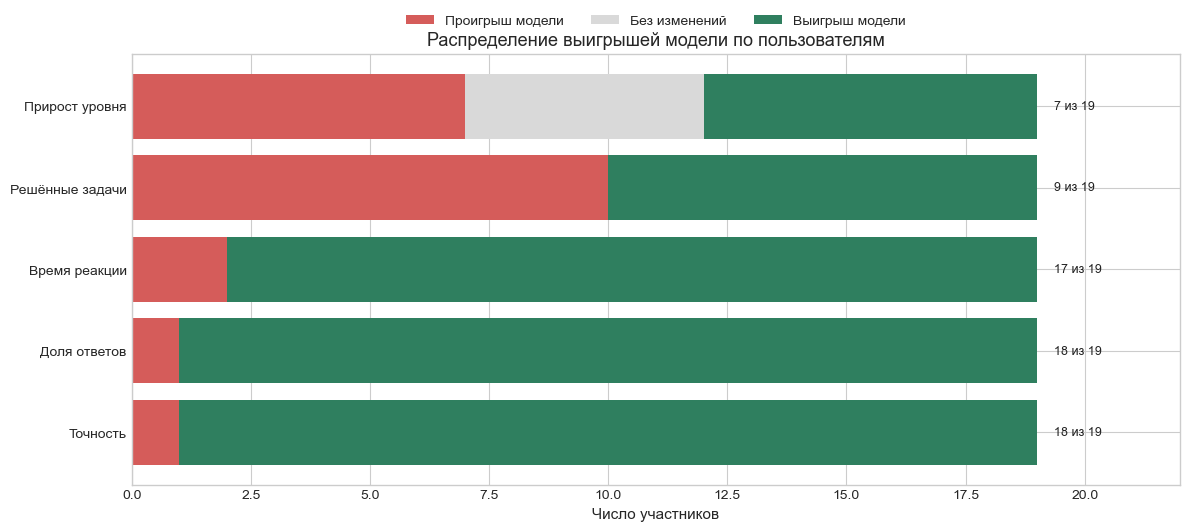

In [38]:
wins_rows = []
metric_specs = [
    ('accuracy_delta_model_minus_baseline', 'Точность', 'positive'),
    ('answered_rate_delta_model_minus_baseline', 'Доля ответов', 'positive'),
    ('rt_delta_model_minus_baseline', 'Время реакции', 'negative'),
    ('solved_delta_model_minus_baseline', 'Решённые задачи', 'positive'),
    ('level_gain_delta_model_minus_baseline', 'Прирост уровня', 'positive'),
]

for column, label, better_when in metric_specs:
    if column not in paired_table.columns:
        continue
    series = paired_table[column].dropna()
    if better_when == 'positive':
        wins = int((series > 0).sum())
        losses = int((series < 0).sum())
    else:
        wins = int((series < 0).sum())
        losses = int((series > 0).sum())
    ties = int((series == 0).sum())
    wins_rows.append({
        'metric': label,
        'wins': wins,
        'losses': losses,
        'ties': ties,
        'total': len(series),
    })

wins_plot_df = pd.DataFrame(wins_rows)
fig, ax = plt.subplots(figsize=(12, 5.4))
y = np.arange(len(wins_plot_df))

ax.barh(y, wins_plot_df['losses'], color='#D55C5A', label='Проигрыш модели')
ax.barh(y, wins_plot_df['ties'], left=wins_plot_df['losses'], color='#D9D9D9', label='Без изменений')
ax.barh(y, wins_plot_df['wins'], left=wins_plot_df['losses'] + wins_plot_df['ties'], color=MODE_COLORS['ppo'], label='Выигрыш модели')

for idx, row in wins_plot_df.iterrows():
    ax.text(
        row['total'] + 0.35,
        idx,
        f"{row['wins']} из {row['total']}",
        va='center',
        ha='left',
        fontsize=9,
        color='#222222',
    )

ax.set_yticks(y, wins_plot_df['metric'])
ax.set_xlabel('Число участников')
ax.set_title('Распределение выигрышей модели по пользователям')
ax.legend(ncol=3, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.12))
ax.set_xlim(0, wins_plot_df['total'].max() + 3)
plt.tight_layout()
plt.show()
